In [5]:
# import packages
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

## Principal Component Analysis

Text(0.5, 0.92, 'Original Data')

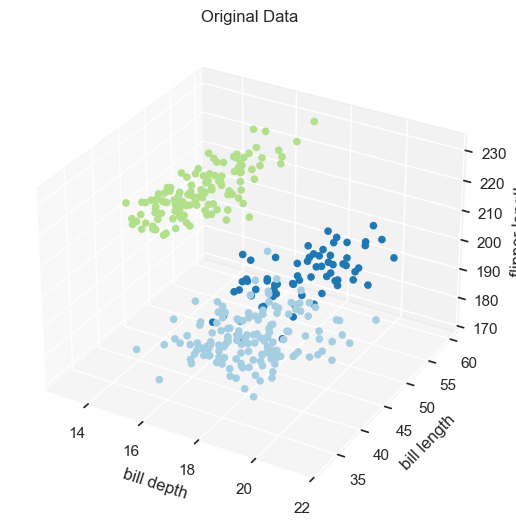

In [6]:
penguins = sns.load_dataset("penguins")

fig = plt.figure()

ax = Axes3D(fig)
fig.add_axes(ax)

cmap = matplotlib.colors.ListedColormap(sns.color_palette("Paired", 3))

cols = penguins['species'].copy()
cols[cols=='Adelie']=1
cols[cols=='Chinstrap']=2
cols[cols=='Gentoo']=3

sc = ax.scatter3D(penguins['bill_depth_mm'],
                penguins['bill_length_mm'],
                penguins['flipper_length_mm'],
                c = cols,
                cmap=cmap,
                alpha=1)
ax.set_xlabel('bill depth')
ax.set_ylabel('bill length')
ax.set_zlabel('flipper length')
ax.set_facecolor((1.0, 1.0, 1.0, 0.0))
ax.set_title('Original Data')

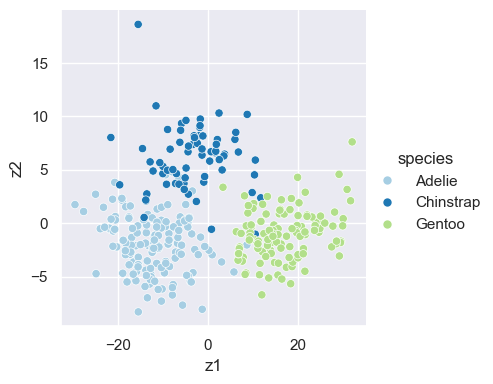

In [10]:
x = penguins[['bill_depth_mm', 'bill_length_mm', 'flipper_length_mm']]
x = x.dropna(axis=0)

pca_fit = PCA()
pca_fit.fit(x)
z = pca_fit.transform(x)

z_df = pd.DataFrame(z[:, 0:2], columns = ['z1', 'z2'])
z_df['species']=penguins['species']

sns.set_theme()
pca_plot = sns.relplot(z_df, x='z1', y='z2', hue='species', palette=sns.color_palette("Paired", 3), height=4)

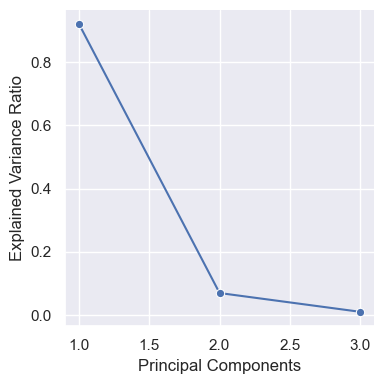

In [8]:
PC_values = np.linspace(1,3,3).reshape(3,1)
scree_df = np.hstack([PC_values, pca_fit.explained_variance_ratio_.reshape(3,1)])
scree_df = pd.DataFrame(scree_df, columns = ['Principal Components', 'Explained Variance Ratio'])
scree_plot = sns.relplot(scree_df, x='Principal Components', y='Explained Variance Ratio', marker='o', kind='line', height=4)